In [32]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

# 1 Dataset

In [33]:
x, y = make_regression(n_samples=100, n_features=1, noise = 10)

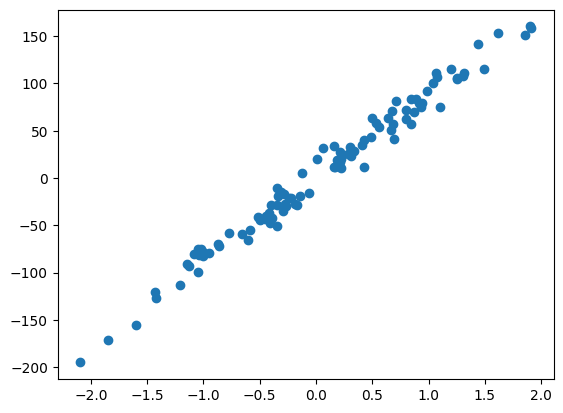

In [34]:
plt.scatter(x,y)

In [35]:
print(x.shape)
print(y.shape)

(100, 1)
(100,)


In [36]:
y = y.reshape(y.shape[0],1)
print(y.shape)

(100, 1)


In [37]:
# matrix X
X = np.hstack((x, np.ones(x.shape)))
X.shape

(100, 2)

In [38]:
X

array([[-0.34648722,  1.        ],
       [-1.14753014,  1.        ],
       [-2.09443986,  1.        ],
       [-0.26350415,  1.        ],
       [ 0.41231715,  1.        ],
       [ 0.29901422,  1.        ],
       [ 1.04219943,  1.        ],
       [-0.95389065,  1.        ],
       [-1.59701606,  1.        ],
       [-0.3939218 ,  1.        ],
       [ 0.20983391,  1.        ],
       [-1.017697  ,  1.        ],
       [ 0.21948899,  1.        ],
       [-0.87156051,  1.        ],
       [-0.51867496,  1.        ],
       [-0.279703  ,  1.        ],
       [-0.28897918,  1.        ],
       [ 0.93124877,  1.        ],
       [ 0.93733423,  1.        ],
       [-1.00443225,  1.        ],
       [-0.12694219,  1.        ],
       [-0.58276544,  1.        ],
       [ 1.25355559,  1.        ],
       [ 0.21140798,  1.        ],
       [ 1.31587057,  1.        ],
       [-1.42906692,  1.        ],
       [-1.04651412,  1.        ],
       [-1.13182842,  1.        ],
       [ 0.80102633,

In [39]:
theta = np.random.randn(2,1)
theta

array([[-0.58262595],
       [ 0.08470349]])

# 2 Modèle

In [40]:
def model(X, theta):
    return X.dot(theta)

In [41]:
model(X, theta)

array([[ 0.28657593],
       [ 0.75328432],
       [ 1.3049785 ],
       [ 0.23822784],
       [-0.15552318],
       [-0.08950996],
       [-0.52250894],
       [ 0.64046493],
       [ 1.01516648],
       [ 0.31421255],
       [-0.03755119],
       [ 0.67764017],
       [-0.0431765 ],
       [ 0.59249726],
       [ 0.38689698],
       [ 0.24766572],
       [ 0.25307025],
       [-0.45786621],
       [-0.46141175],
       [ 0.66991178],
       [ 0.1586633 ],
       [ 0.42423776],
       [-0.64565053],
       [-0.03846828],
       [-0.68195685],
       [ 0.91731496],
       [ 0.69442977],
       [ 0.7441361 ],
       [-0.38199524],
       [-0.20142899],
       [ 0.28682953],
       [-0.78321942],
       [ 0.05048067],
       [ 0.36859329],
       [-0.31725591],
       [ 0.11914354],
       [ 0.69499754],
       [-0.20677606],
       [-0.16529658],
       [ 0.22248315],
       [ 0.08174273],
       [-0.33182107],
       [-0.10942006],
       [ 0.21576523],
       [ 0.3249865 ],
       [-0

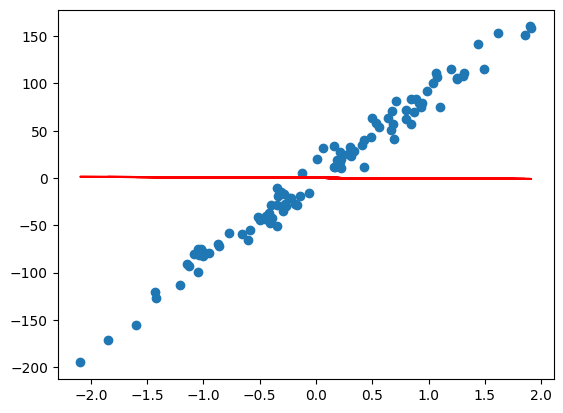

In [42]:
plt.scatter(x, y)
plt.plot(x, model(X, theta), color = "red")

# Cost Functions

In [43]:
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((model(X, theta) - y) ** 2)

In [44]:
cost_function(X, y, theta)

np.float64(2991.929236252333)

# Gradient & Gradient Descent

In [45]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

In [46]:
def GradientDescent(X, y, theta, learning_rate, n_iteration):
    cost_history = np.zeros(n_iteration)
    for i in range(0, n_iteration):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)
    return theta, cost_history


# Machine Learning !!!

In [47]:
theta_final, cost_history = GradientDescent(X, y, theta, learning_rate=0.01, n_iteration=1000)

In [48]:
theta_final

array([[86.98875911],
       [ 0.84346761]])

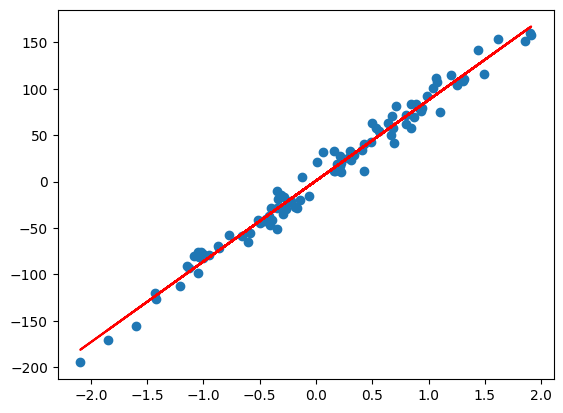

In [49]:
predictions = model(X, theta_final)
plt.scatter(x,y)
plt.plot(x, predictions, color = "red")

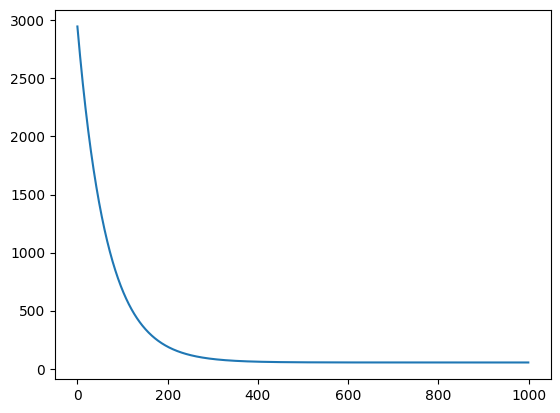

In [50]:
plt.plot(range(1000), cost_history)

# Coefficient de détermination R^2

In [51]:
def coef_determination(y, pred):
    u = ((y - pred) ** 2).sum()
    v = ((y - y.mean()) ** 2).sum()
    R_carre = 1 - ( u / v )
    return R_carre

In [52]:
coef_determination(y, predictions)

np.float64(0.9816107224340911)